In [ ]:
# Sleep Efficiency 모델링에 사용할
# 전처리 담당자의 전처리 결과를 불러옴.
#
# 모델 학습 전에 저장된 Train/Test 데이터,
# 전처리 객체 및 Feature 구성을 확인
import joblib

preprocessing_data = joblib.load(
    "../risk_data/efficiency_prep_yt_ver.pkl"
)

print("=== PKL 데이터 타입 ===")
print(type(preprocessing_data))

if isinstance(preprocessing_data, dict):
    print("\n=== 저장된 항목 ===")
    for key in preprocessing_data.keys():
        print(key)

=== PKL 데이터 타입 ===
<class 'dict'>

=== 저장된 항목 ===
X_train
X_test
y_train
y_test
scaler
encoder
numeric_features
categorical_features
outlier_bounds


In [ ]:
# Sleep Efficiency 전처리 데이터 확인

X_train = preprocessing_data["X_train"]
X_test = preprocessing_data["X_test"]
y_train = preprocessing_data["y_train"]
y_test = preprocessing_data["y_test"]

scaler = preprocessing_data["scaler"]
encoder = preprocessing_data["encoder"]

numeric_features = preprocessing_data["numeric_features"]
categorical_features = preprocessing_data["categorical_features"]
outlier_bounds = preprocessing_data["outlier_bounds"]


print("=== 데이터 크기 ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\n=== 숫자형 Feature ===")
print(numeric_features)

print("\n=== 범주형 Feature ===")
print(categorical_features)

print("\n=== 이상치 처리 기준 ===")
print(outlier_bounds)

=== 데이터 크기 ===
X_train: (24000, 16)
X_test : (6000, 16)
y_train: (24000,)
y_test : (6000,)

=== 숫자형 Feature ===
['Age', 'BMI', 'Sleep_Duration', 'Daytime_Sleepiness', 'Caffeine_Intake_mg', 'Physical_Activity_Minutes', 'Screen_Time_Hours']

=== 범주형 Feature ===
['Gender', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption']

=== 이상치 처리 기준 ===
{'Caffeine_Intake_mg': (0, np.float64(395.0)), 'Physical_Activity_Minutes': (0, np.float64(104.4))}


In [4]:
print("\n=== y_train 통계 ===")
print(y_train.describe())

print("\n=== y_test 통계 ===")
print(y_test.describe())


=== y_train 통계 ===
count    24000.000000
mean        83.714646
std          7.732480
min         57.000000
25%         78.000000
50%         83.700000
75%         89.600000
max         99.000000
Name: Sleep_Efficiency, dtype: float64

=== y_test 통계 ===
count    6000.000000
mean       83.582617
std         7.746919
min        59.600000
25%        77.975000
50%        83.500000
75%        89.400000
max        99.000000
Name: Sleep_Efficiency, dtype: float64


In [5]:
# One-Hot Encoding으로 생성된 Feature 확인

encoded_features = encoder.get_feature_names_out(
    categorical_features
)

final_features = (
    numeric_features
    + list(encoded_features)
)

print("=== 최종 Feature ===")

for i, feature in enumerate(final_features, start=1):
    print(f"{i}. {feature}")

print("\n최종 Feature 수:", len(final_features))

=== 최종 Feature ===
1. Age
2. BMI
3. Sleep_Duration
4. Daytime_Sleepiness
5. Caffeine_Intake_mg
6. Physical_Activity_Minutes
7. Screen_Time_Hours
8. Gender_Female
9. Gender_Male
10. Stress_Level_High
11. Stress_Level_Low
12. Stress_Level_Medium
13. Smoking_Status_No
14. Smoking_Status_Yes
15. Alcohol_Consumption_No
16. Alcohol_Consumption_Yes

최종 Feature 수: 16


In [6]:
# Random Forest Baseline
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_model = RandomForestRegressor(
    random_state=42
)

# 모델 학습
rf_model.fit(X_train, y_train)

# Train / Test 예측
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)


# Train 성능
rf_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_rf
    )
)

rf_train_r2 = r2_score(
    y_train,
    y_train_pred_rf
)


# Test 성능
rf_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_rf
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_rf
    )
)

rf_test_r2 = r2_score(
    y_test,
    y_test_pred_rf
)


print("=== Random Forest Baseline Train ===")
print(f"MAE  : {rf_train_mae:.4f}")
print(f"RMSE : {rf_train_rmse:.4f}")
print(f"R²   : {rf_train_r2:.4f}")

print("\n=== Random Forest Baseline Test ===")
print(f"MAE  : {rf_test_mae:.4f}")
print(f"RMSE : {rf_test_rmse:.4f}")
print(f"R²   : {rf_test_r2:.4f}")

=== Random Forest Baseline Train ===
MAE  : 1.3865
RMSE : 1.7388
R²   : 0.9494

=== Random Forest Baseline Test ===
MAE  : 3.7183
RMSE : 4.6309
R²   : 0.6426


### Random Forest Baseline 결과 해석

- Train R²는 **0.9494**, Test R²는 **0.6426**으로 나타남
- Test 데이터에서 Sleep Efficiency 변동의 약 **64.3%를 설명**하는 성능을 보임
- Test MAE는 **3.7183**으로, 예측값이 실제 Sleep Efficiency와 평균적으로 약 **3.72 정도 차이**남
- Test RMSE는 **4.6309**로 MAE보다 크게 나타나 일부 데이터에서 비교적 큰 예측 오차가 발생한 것으로 볼 수 있음
- Train과 Test 성능 차이가 크게 나타나 기본 Random Forest 모델이 학습 데이터에 **과적합된 가능성**이 있음
- 따라서 Random Forest만으로 최종 모델을 결정하지 않고 다른 회귀 모델과 성능 및 일반화 정도를 비교할 필요가 있음

In [7]:
# Linear Regression
#
# Sleep Efficiency와 주요 입력 Feature 사이에서
# 비교적 강한 선형 상관관계가 확인되었으므로,       => Daytime_Sleepiness, Stress_Level, Sleep_Duration
# 선형 관계를 기반으로 하는 Linear Regression의 성능을 확인함.
from sklearn.linear_model import LinearRegression



linear_model = LinearRegression()

# 모델 학습
linear_model.fit(X_train, y_train)

# Train / Test 예측
y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

# Train 성능
linear_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_linear
)

linear_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_linear
    )
)

linear_train_r2 = r2_score(
    y_train,
    y_train_pred_linear
)

# Test 성능
linear_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_linear
)

linear_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_linear
    )
)

linear_test_r2 = r2_score(
    y_test,
    y_test_pred_linear
)

print("=== Linear Regression Train ===")
print(f"MAE  : {linear_train_mae:.4f}")
print(f"RMSE : {linear_train_rmse:.4f}")
print(f"R²   : {linear_train_r2:.4f}")

print("\n=== Linear Regression Test ===")
print(f"MAE  : {linear_test_mae:.4f}")
print(f"RMSE : {linear_test_rmse:.4f}")
print(f"R²   : {linear_test_r2:.4f}")

=== Linear Regression Train ===
MAE  : 3.6290
RMSE : 4.5112
R²   : 0.6596

=== Linear Regression Test ===
MAE  : 3.6207
RMSE : 4.4964
R²   : 0.6631


### Linear Regression 결과 해석

- Train R²는 **0.6596**, Test R²는 **0.6631**로 나타남
- Test 데이터에서 Sleep Efficiency 변동의 약 **66.3%를 설명**하는 성능을 보임
- Test MAE는 **3.6207**로, 예측값이 실제 Sleep Efficiency와 평균적으로 약 **3.62 정도 차이**남
- Test RMSE는 **4.4964**로 일부 데이터에서는 평균보다 큰 예측 오차가 존재함
- Train과 Test의 MAE, RMSE, R²가 매우 유사하여 학습 데이터와 테스트 데이터에서 **안정적인 성능**을 보임
- Random Forest Baseline보다 Test MAE와 RMSE가 낮고 R²가 높게 나타남
- Random Forest에서 나타난 큰 Train/Test 성능 차이가 Linear Regression에서는 나타나지 않아 **일반화 성능이 상대적으로 안정적**인 것으로 판단됨

In [8]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

# 모델 학습
gb_model.fit(X_train, y_train)

# Train / Test 예측
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)


# Train 성능
gb_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_gb
)

gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_gb
    )
)

gb_train_r2 = r2_score(
    y_train,
    y_train_pred_gb
)


# Test 성능
gb_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_gb
)

gb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_gb
    )
)

gb_test_r2 = r2_score(
    y_test,
    y_test_pred_gb
)


print("=== Gradient Boosting Train ===")
print(f"MAE  : {gb_train_mae:.4f}")
print(f"RMSE : {gb_train_rmse:.4f}")
print(f"R²   : {gb_train_r2:.4f}")

print("\n=== Gradient Boosting Test ===")
print(f"MAE  : {gb_test_mae:.4f}")
print(f"RMSE : {gb_test_rmse:.4f}")
print(f"R²   : {gb_test_r2:.4f}")

=== Gradient Boosting Train ===
MAE  : 3.5909
RMSE : 4.4664
R²   : 0.6664

=== Gradient Boosting Test ===
MAE  : 3.6264
RMSE : 4.5024
R²   : 0.6622


### Gradient Boosting 결과 해석

- Train R²는 **0.6664**, Test R²는 **0.6622**로 나타남
- Test 데이터에서 Sleep Efficiency 변동의 약 **66.2%를 설명**하는 성능을 보임
- Test MAE는 **3.6264**, RMSE는 **4.5024**로 나타남
- Train과 Test 성능이 유사하여 Random Forest와 달리 큰 과적합 현상은 나타나지 않음
- Random Forest보다 Test 성능이 개선되었으나 Linear Regression과는 거의 동일한 성능을 보임
- Linear Regression보다 복잡한 모델임에도 Test MAE, RMSE, R²에서 추가적인 성능 향상은 확인되지 않음

In [9]:
# Random Forest Hyperparameter Tuning
#
# Baseline Random Forest에서 Train R²(0.9494)와
# Test R²(0.6426)의 차이가 크게 나타나 과적합 가능성을 확인함.
#
# Tree의 최대 깊이와 분할 조건 등을 제한하여
# 모델의 복잡도를 낮추고 Test 데이터에 대한
# 일반화 성능이 개선되는지 확인함.

rf_tuned_model = RandomForestRegressor(
    n_estimators=200,       # 생성할 Decision Tree 개수
    max_depth=10,           # Tree의 최대 깊이를 제한하여 과적합 방지
    min_samples_split=10,   # 노드를 분할하기 위한 최소 데이터 수
    min_samples_leaf=5,     # Leaf Node가 가져야 하는 최소 데이터 수
    max_features="sqrt",    # 각 Tree 분할 시 사용할 Feature 수 제한
    random_state=42,
    n_jobs=-1
)

# 모델 학습
rf_tuned_model.fit(X_train, y_train)

# Train / Test 예측
y_train_pred_rf_tuned = rf_tuned_model.predict(X_train)
y_test_pred_rf_tuned = rf_tuned_model.predict(X_test)


# Train 성능
rf_tuned_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf_tuned
)

rf_tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_rf_tuned
    )
)

rf_tuned_train_r2 = r2_score(
    y_train,
    y_train_pred_rf_tuned
)


# Test 성능
rf_tuned_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_rf_tuned
)

rf_tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_rf_tuned
    )
)

rf_tuned_test_r2 = r2_score(
    y_test,
    y_test_pred_rf_tuned
)


print("=== Tuned Random Forest Train ===")
print(f"MAE  : {rf_tuned_train_mae:.4f}")
print(f"RMSE : {rf_tuned_train_rmse:.4f}")
print(f"R²   : {rf_tuned_train_r2:.4f}")

print("\n=== Tuned Random Forest Test ===")
print(f"MAE  : {rf_tuned_test_mae:.4f}")
print(f"RMSE : {rf_tuned_test_rmse:.4f}")
print(f"R²   : {rf_tuned_test_r2:.4f}")

=== Tuned Random Forest Train ===
MAE  : 3.4710
RMSE : 4.3120
R²   : 0.6890

=== Tuned Random Forest Test ===
MAE  : 3.6448
RMSE : 4.5217
R²   : 0.6593


### Random Forest 하이퍼파라미터 튜닝 결과 해석

- Baseline Random Forest의 Train R²는 **0.9494**, Test R²는 **0.6426**으로 Train/Test 성능 차이가 크게 나타남
- Tree 깊이와 분할 조건 등을 제한하여 모델의 복잡도를 낮춘 결과, Train R²는 **0.6890**, Test R²는 **0.6593**으로 나타남
- Test MAE는 **3.7183 → 3.6448**, RMSE는 **4.6309 → 4.5217**로 감소하여 Baseline 대비 예측 오차가 개선됨
- Train/Test R² 차이가 크게 감소하여 Baseline 모델에서 나타난 과적합이 완화된 것으로 판단됨
- 튜닝을 통해 Random Forest의 일반화 성능이 개선되었지만, Linear Regression 및 다른 모델과의 성능 비교를 통해 최종 모델을 선정함

In [ ]:
# GridSearchCV를 사용하여 Random Forest의
# 여러 하이퍼파라미터 조합을 자동으로 비교함.
#
# Baseline 모델에서 과적합이 확인되었으므로,
# Tree의 깊이와 분할 조건 등을 조정하여
# 일반화 성능이 가장 좋은 조합을 탐색함.
#
# cv=5를 사용하여 Train 데이터를 5개로 나누어
# 교차 검증을 수행하고,
# MAE가 가장 낮은 조합을 선택함.
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200, 300],    # 3
    "max_depth": [5, 10, 15],           # 3
    "min_samples_split": [5, 10, 20],   # 3
    "min_samples_leaf": [2, 5, 10],     # 3
    "max_features": ["sqrt", 0.5]       # 2
}

rf_grid_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_grid_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,                               # 5
    n_jobs=-1,
    verbose=1
)

# 3 * 3 * 3 * 3 * 2 = 162
# 162 * 5 = 810

grid_search.fit(X_train, y_train)

print("=== Best Parameters ===")
print(grid_search.best_params_)

print("\n=== Best CV MAE ===")
print(-grid_search.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
=== Best Parameters ===
{'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 300}

=== Best CV MAE ===
3.6446924478230533


### Random Forest GridSearch 결과 해석

- 총 **162개의 하이퍼파라미터 조합**에 대해 5-Fold 교차 검증을 수행하여 총 **810번의 학습**을 진행함
- 교차 검증 결과 가장 낮은 MAE를 보인 최적의 하이퍼파라미터 조합은 다음과 같음
    - `n_estimators`: **300**
    - `max_depth`: **10**
    - `min_samples_split`: **5**
    - `min_samples_leaf`: **10**
    - `max_features`: **0.5**
- 최적 조합의 교차 검증 평균 MAE는 약 **3.6447**로 나타남
- Baseline Random Forest에서 과적합이 확인되었기 때문에 Tree의 깊이, 분할 조건, Leaf Node의 최소 데이터 수 등을 여러 조합으로 비교하여 일반화 성능이 좋은 설정을 탐색함
- 특히 `max_depth=10`, `min_samples_leaf=10`이 선택되어 Tree의 복잡도를 제한하는 방향의 하이퍼파라미터가 최적 조합으로 선정됨
- 해당 결과는 Train 데이터 내부의 교차 검증 결과이므로, 최종적으로 선택된 모델을 Test 데이터에 적용하여 실제 일반화 성능을 추가로 확인할 필요가 있음

In [ ]:
# GridSearchCV에서 선택된 최적 Random Forest 모델을 사용하여
# 최종적으로 선택된 모델이 학습에 사용되지 않은 Test 데이터에서도
# 안정적인 성능을 보이는지 확인함.

rf_grid_best_model = grid_search.best_estimator_

# Train / Test 예측
y_train_pred_rf_grid = rf_grid_best_model.predict(X_train)
y_test_pred_rf_grid = rf_grid_best_model.predict(X_test)


# Train 성능
rf_grid_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf_grid
)

rf_grid_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_rf_grid
    )
)

rf_grid_train_r2 = r2_score(
    y_train,
    y_train_pred_rf_grid
)


# Test 성능
rf_grid_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_rf_grid
)

rf_grid_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_rf_grid
    )
)

rf_grid_test_r2 = r2_score(
    y_test,
    y_test_pred_rf_grid
)


print("=== GridSearch Random Forest Train ===")
print(f"MAE  : {rf_grid_train_mae:.4f}")
print(f"RMSE : {rf_grid_train_rmse:.4f}")
print(f"R²   : {rf_grid_train_r2:.4f}")

print("\n=== GridSearch Random Forest Test ===")
print(f"MAE  : {rf_grid_test_mae:.4f}")
print(f"RMSE : {rf_grid_test_rmse:.4f}")
print(f"R²   : {rf_grid_test_r2:.4f}")

=== GridSearch Random Forest Train ===
MAE  : 3.4329
RMSE : 4.2712
R²   : 0.6949

=== GridSearch Random Forest Test ===
MAE  : 3.6367
RMSE : 4.5117
R²   : 0.6608


### GridSearch Random Forest 최종 평가

- GridSearch로 선정된 최적 Random Forest의 Train R²는 **0.6949**, Test R²는 **0.6608**로 나타남
- Test MAE는 **3.6367**, RMSE는 **4.5117**로 나타남
- Baseline Random Forest의 Test R² **0.6426**보다 향상되어 하이퍼파라미터 튜닝을 통한 성능 개선을 확인함
- Train R² 역시 Baseline의 **0.9494 → 0.6949**로 낮아지고 Train/Test 성능 차이가 감소하여 과적합이 크게 완화됨
- 직접 튜닝한 Random Forest보다 Test MAE, RMSE, R²가 모두 소폭 개선되어 GridSearch를 통한 하이퍼파라미터 탐색의 효과를 확인함
- 다만 Linear Regression과 Gradient Boosting보다 Test 성능이 소폭 낮게 나타남

### 정리

Random Forest의 과적합을 확인하여 직접 하이퍼파라미터 튜닝을 수행한 뒤, 162개의 하이퍼파라미터 조합에 대해 5-Fold 교차 검증을 적용하여 총 810회의 학습을 수행했다. 그 결과 최적의 Random Forest 모델을 선정했으나, Linear Regression이 MAE, RMSE, R²에서 가장 우수한 Test 성능을 보였다. 또한 Train/Test 성능 차이가 작고 모델 구조가 단순하여 Linear Regression을 최종 모델로 선정하였다.

In [12]:
# 모델 성능 비교
#
# Baseline Random Forest, 직접 튜닝 Random Forest,
# GridSearch Random Forest, Linear Regression,
# Gradient Boosting의 Test 성능을 동일한 평가 지표로 비교함.

import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest Baseline",
        "Random Forest Tuned",
        "Random Forest GridSearch",
        "Linear Regression",
        "Gradient Boosting"
    ],

    "Train MAE": [
        rf_train_mae,
        rf_tuned_train_mae,
        rf_grid_train_mae,
        linear_train_mae,
        gb_train_mae
    ],

    "Test MAE": [
        rf_test_mae,
        rf_tuned_test_mae,
        rf_grid_test_mae,
        linear_test_mae,
        gb_test_mae
    ],

    "Test RMSE": [
        rf_test_rmse,
        rf_tuned_test_rmse,
        rf_grid_test_rmse,
        linear_test_rmse,
        gb_test_rmse
    ],

    "Test R²": [
        rf_test_r2,
        rf_tuned_test_r2,
        rf_grid_test_r2,
        linear_test_r2,
        gb_test_r2
    ]
})

# Test MAE가 낮은 순서대로 정렬
model_comparison = (
    model_comparison
    .sort_values(
        by="Test MAE"
    )
    .reset_index(drop=True)
)

print("=== 모델 성능 비교 ===")
display(
    model_comparison.round(4)
)

=== 모델 성능 비교 ===


,Model,Train MAE,Test MAE,Test RMSE,Test R²
0,Linear Regression,3.6290,3.6207,4.4964,0.6631
1,Gradient Boosting,3.5909,3.6264,4.5024,0.6622
2,Random Forest GridSearch,3.4329,3.6367,4.5117,0.6608
3,Random Forest Tuned,3.4710,3.6448,4.5217,0.6593
4,Random Forest Baseline,1.3865,3.7183,4.6309,0.6426


### 최종 모델 선정

- Random Forest Baseline, Linear Regression, Gradient Boosting 모델을 비교하고 Random Forest의 과적합 개선을 위해 추가적인 하이퍼파라미터 튜닝을 수행함
- Random Forest Baseline은 Train R² **0.9494**, Test R² **0.6426**으로 큰 성능 차이가 나타나 과적합 가능성을 확인함
- 직접 하이퍼파라미터를 조정하여 과적합을 완화하고 Test 성능을 개선함
- 추가로 162개의 하이퍼파라미터 조합에 5-Fold 교차 검증을 적용하여 총 **810회의 학습**을 수행함
- GridSearch를 통해 Random Forest의 Test R²를 **0.6608**까지 개선했지만 Linear Regression의 Test 성능을 넘지는 못함
- Linear Regression은 Test MAE **3.6207**, RMSE **4.4964**, R² **0.6631**로 비교한 모델 중 가장 좋은 Test 성능을 기록함
- 또한 Train R² **0.6596**, Test R² **0.6631**로 Train/Test 성능 차이가 거의 없어 안정적인 일반화 성능을 보임
- Gradient Boosting은 Linear Regression과 매우 유사한 성능을 보였지만 더 복잡한 모델임에도 추가적인 성능 향상이 나타나지 않음

따라서 **예측 성능, 일반화 성능, 모델의 단순성과 해석 용이성을 종합적으로 고려하여 Linear Regression을 최종 Sleep Efficiency 예측 모델로 선정함.**

In [ ]:
# 최종 Sleep Efficiency 예측 모델 패키지 구성
#
# 새로운 사용자 입력값에도 학습 당시와 동일한 전처리를 적용할 수 있도록
# Linear Regression 모델과 전처리 객체 및 Feature 정보를 함께 저장함.
import joblib

final_model_package = {
    "model": linear_model,
    "scaler": scaler,
    "encoder": encoder,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "outlier_bounds": outlier_bounds,
    "target": "Sleep_Efficiency"
}

# 최종 모델 저장
joblib.dump(
    final_model_package,
    "../risk_data/efficiency_sleep_efficiency_model.pkl"
)

print("Sleep Efficiency 모델 저장 완료")

Sleep Efficiency 모델 저장 완료


In [16]:
# 저장된 모델 패키지 확인

loaded_model_package = joblib.load(
    "../risk_data/efficiency_sleep_efficiency_model.pkl"
)

print("=== 저장된 항목 ===")

for key in loaded_model_package.keys():
    print(key)

=== 저장된 항목 ===
model
scaler
encoder
numeric_features
categorical_features
outlier_bounds
target


### 최종 모델 예측 테스트

- 최종 모델로 선정한 Linear Regression을 전처리 객체와 함께 `.pkl` 파일로 저장함
- 별도의 테스트 코드에서 저장된 모델과 전처리 객체를 불러와 실제 서비스와 유사한 단일 사용자 입력에 대한 예측을 수행함
- 사용자 입력에 학습 데이터와 동일한 이상치 처리, Standard Scaling, One-Hot Encoding을 적용한 후 모델에 입력함
- 테스트 결과 Sleep Efficiency 예측값은 **84.83**으로 정상적으로 출력됨
- 이를 통해 저장된 모델과 전처리 파이프라인이 정상적으로 동작하며 새로운 사용자 입력에 대한 예측이 가능함을 확인함

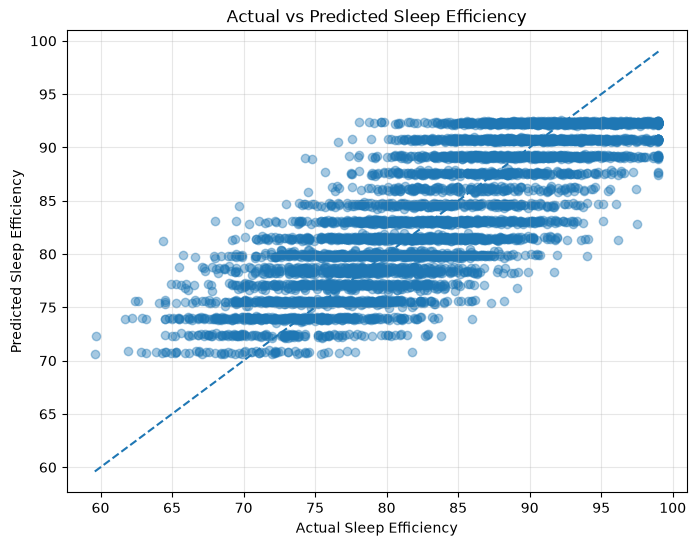

In [17]:
# Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred_linear,
    alpha=0.4
)

# 실제값 = 예측값인 기준선
min_value = min(
    y_test.min(),
    y_test_pred_linear.min()
)

max_value = max(
    y_test.max(),
    y_test_pred_linear.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sleep Efficiency")
plt.ylabel("Predicted Sleep Efficiency")
plt.title("Actual vs Predicted Sleep Efficiency")

plt.grid(alpha=0.3)
plt.show()

### Actual vs Predicted 결과 해석

- 실제 Sleep Efficiency가 증가할수록 예측값도 증가하는 전반적인 양의 관계가 확인됨
- 예측값이 기준선 주변에 분포하여 모델이 Sleep Efficiency의 전체적인 변화 경향을 학습한 것을 확인함
- 실제값이 낮은 구간에서는 실제보다 높게 예측하고, 높은 구간에서는 실제보다 낮게 예측하는 경향이 나타남
- 특히 극단적인 Sleep Efficiency 값에서는 예측값이 평균적인 범위로 모이는 특성이 확인됨
- 따라서 모델은 전반적인 Sleep Efficiency 예측에는 활용할 수 있으나, 매우 낮거나 높은 값에 대해서는 예측 오차가 증가할 수 있음

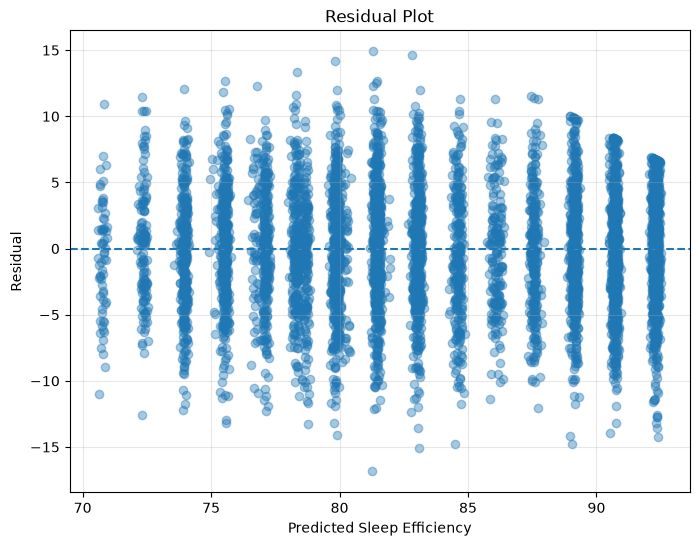

In [18]:
# Residual Plot
#
# 실제값과 예측값의 차이(Residual)를 확인하여
# 모델의 예측 오차가 특정 구간에 치우쳐 있는지 확인함.
#
# Residual이 0을 중심으로 특별한 패턴 없이 분포한다면
# 모델의 오차가 비교적 안정적으로 나타난다고 볼 수 있음.

residuals = y_test - y_test_pred_linear

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred_linear,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sleep Efficiency")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.grid(alpha=0.3)
plt.show()

### Residual Plot 결과 해석

- 잔차는 전반적으로 0을 중심으로 양수와 음수 영역에 분포함
- 비슷한 예측값을 갖는 데이터가 다수 존재하여 점들이 세로 방향으로 밀집된 형태가 나타남
- 이러한 세로 형태만으로 모델이 특정 비선형 관계를 설명하지 못한다고 판단할 수는 없음
- 다만 일부 구간에서 비교적 큰 양수 및 음수 잔차가 확인되어 모든 데이터를 정확하게 예측하지는 못함
- Actual vs Predicted 결과와 함께 확인했을 때, 특히 극단적인 실제값에서 예측 오차가 증가하는 한계가 있음

In [19]:
# Linear Regression Feature별 계수 확인

# One-Hot Encoding 이후 범주형 Feature 이름
encoded_feature_names = (
    encoder
    .get_feature_names_out(categorical_features)
    .tolist()
)

# 최종 Feature 이름
feature_names = (
    numeric_features
    + encoded_feature_names
)

# Linear Regression 계수
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
})

# 영향 방향
coef_df["Direction"] = coef_df["Coefficient"].apply(
    lambda x: "Positive" if x > 0 else "Negative"
)

# 절댓값 기준 정렬
coef_df["Abs_Coefficient"] = (
    coef_df["Coefficient"].abs()
)

coef_df = (
    coef_df
    .sort_values(
        "Abs_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=== Linear Regression Feature Coefficients ===")

display(
    coef_df[
        [
            "Feature",
            "Coefficient",
            "Direction"
        ]
    ].round(4)
)

=== Linear Regression Feature Coefficients ===


,Feature,Coefficient,Direction
0,Stress_Level_Low,3.8972,Positive
1,Daytime_Sleepiness,-3.6761,Negative
2,Stress_Level_High,-3.3546,Negative
3,Stress_Level_Medium,-0.5426,Negative
4,BMI,-0.0621,Negative
5,Smoking_Status_Yes,-0.0573,Negative
6,Smoking_Status_No,0.0573,Positive
7,Age,-0.0317,Negative
8,Gender_Male,0.0271,Positive
9,Gender_Female,-0.0271,Negative


### Linear Regression Feature 계수 분석

- Linear Regression의 Feature별 계수를 확인하여 각 입력 변수가 Sleep Efficiency 예측에 작용하는 방향을 분석함
- `Stress_Level`과 `Daytime_Sleepiness` 관련 Feature의 계수 절댓값이 다른 Feature보다 크게 나타나 모델의 주요 예측 변수로 확인됨
- `Daytime_Sleepiness`는 음의 계수(-3.6761)를 보여 주간 졸림이 증가할수록 Sleep Efficiency 예측값이 감소하는 방향으로 작용함
- `Stress_Level_Low`는 양의 방향, `Stress_Level_High`는 음의 방향으로 나타나 스트레스 수준에 따라 Sleep Efficiency 예측값에 큰 차이가 나타남
- `Sleep_Duration`은 Sleep Efficiency와 개별적으로 비교했을 때 양의 상관관계가 확인되었지만, 다른 Feature를 함께 고려한 Linear Regression에서는 계수가 상대적으로 작게 나타남
- 따라서 단순 상관관계와 여러 변수를 동시에 고려한 회귀계수의 영향은 서로 다를 수 있음을 확인함
- 범주형 Feature는 One-Hot Encoding된 변수를 모두 포함하고 있으므로 개별 더미 변수의 계수 절댓값보다는 범주 간 상대적인 차이를 중심으로 해석함
- 이러한 관계는 모델이 학습한 데이터에서 나타난 통계적 관계이며 실제 인과관계를 의미하지 않음

In [20]:
# 최종 모델 예측 결과 확인
#
# Test 데이터에 대한 실제 Sleep Efficiency와
# Linear Regression의 예측 결과를 비교함.

result_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred_linear
})

# 절대 오차 계산
result_df["Absolute_Error"] = (
    result_df["Actual"] - result_df["Predicted"]
).abs()

print("=== 최종 모델 주요 성능 지표 ===")

performance_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Score": [
        linear_test_mae,
        linear_test_rmse,
        linear_test_r2
    ]
})

display(
    performance_df.round(4)
)

print("\n=== 실제값 / 예측값 비교 ===")

display(
    result_df.head(10).round(2)
)

=== 최종 모델 주요 성능 지표 ===


,Metric,Score
0,MAE,3.6207
1,RMSE,4.4964
2,R²,0.6631



=== 실제값 / 예측값 비교 ===


,Actual,Predicted,Absolute_Error
0,74.7,82.85,8.15
1,70.5,72.35,1.85
2,67.6,72.43,4.83
3,83.0,79.92,3.08
4,79.1,77.04,2.06
5,92.3,87.50,4.80
6,88.2,84.33,3.87
7,77.8,76.66,1.14
8,81.4,79.83,1.57
9,81.9,79.78,2.12


### 최종 모델 성능

- 최종 모델인 Linear Regression을 Test 데이터 6,000건에 적용하여 성능을 평가함
- MAE는 **3.6207**로 실제 Sleep Efficiency와 예측값 사이에 평균적으로 약 **3.62의 절대 오차**가 발생함
- RMSE는 **4.4964**로 나타나 일부 데이터에서 평균보다 큰 예측 오차가 존재함
- R²는 **0.6631**로 Test 데이터의 Sleep Efficiency 변동 중 약 **66.3%를 모델이 설명함**
- 실제값과 예측값 비교를 통해 새로운 데이터에서도 전반적인 Sleep Efficiency 변화 경향을 예측하는 것을 확인함